In [1]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, utils, datasets

remember to add the datafiles

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
atlantic_hur_dat = pd.read_csv('Processed_hurricane_florida_data.csv', index_col = 'date')
atlantic_hur_dat.drop(atlantic_hur_dat.columns[0], axis = 1, inplace = True)
atlantic_hur_dat.loc[atlantic_hur_dat['min_pressure'] == -999, 'min_pressure'] = np.nan
atlantic_hur_dat.loc[atlantic_hur_dat['max_wind'] == -999, 'max_wind'] = np.nan
print(len(atlantic_hur_dat))
atlantic_hur_dat.columns

54749


Index(['storm_id', 'storm_name', 'time', 'status', 'latitude', 'longitude',
       'max_wind', 'min_pressure', 'category'],
      dtype='object')

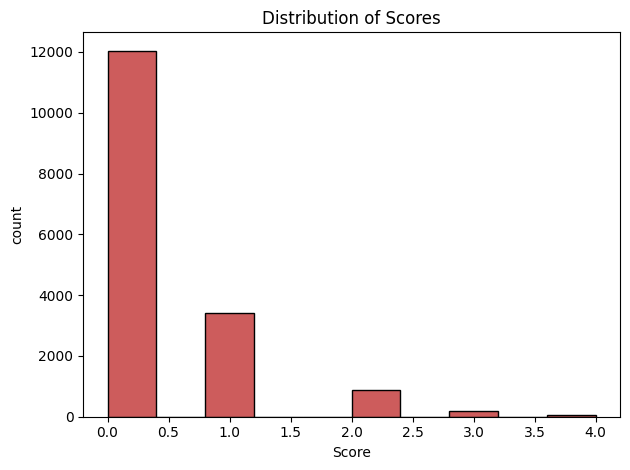

In [ ]:
plt.hist(atlantic_hur_dat['category'], color = 'indianred', edgecolor = 'k')
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('count')
plt.tight_layout()
plt.show()

#### I begin witha simple model classifiying hurricane score based on wind (which is a direct relationship so the simple network should beable to do this)

##### define the dataloader

In [4]:
class DataSet_model1(Dataset):
    def __init__(self, data, labels):
      if isinstance(data, torch.Tensor):
        self.data = data
        self.labels = labels
      else:
        self.data = torch.tensor(data, dtype = torch.float32)
        self.labels = torch.tensor(labels, dtype = torch.long)

    def __len__(self):
      return len(self.data)

    def __getitem__(self, index):
       return self.data[index], self.labels[index]


In [5]:
# atlantic_hur_dat = atlantic_hur_dat.dropna(subset=['max_wind', 'category'])

train = atlantic_hur_dat[:int(len(atlantic_hur_dat)*.6)]
validate = atlantic_hur_dat[int(len(atlantic_hur_dat)*.6): int(len(atlantic_hur_dat)*.7)]
test = atlantic_hur_dat[int(len(atlantic_hur_dat)*.7):]

# train_dataloader = DataLoader(DataSet_model1(train['max_wind'].values, train['category'].values), batch_size = 40, shuffle = True, num_workers = 2)
# validate_dataloader = DataLoader(DataSet_model1(train['max_wind'].values, train['category'].values), batch_size = 40, shuffle = True, num_workers = 2)
# test_dataloader = DataLoader(DataSet_model1(train['max_wind'].values, train['category'].values), batch_size = 40, shuffle = False, num_workers = 2)


def create_sequences(data, labels, sequence_length):
    sequences = []
    sequence_labels = []
    for i in range(len(data) - sequence_length):
        seq = data[i:i+sequence_length]
        sequences.append(seq)
        sequence_labels.append(labels[i+sequence_length-1])
    return torch.tensor(np.array(sequences), dtype=torch.float32), torch.tensor(np.array(sequence_labels), dtype=torch.long)


sequence_length = 5
train_sequences, train_labels = create_sequences(train['max_wind'].values, train['category'].values, sequence_length)
validate_sequences, validate_labels = create_sequences(validate['max_wind'].values, validate['category'].values, sequence_length)
test_sequences, test_labels = create_sequences(test['max_wind'].values, test['category'].values, sequence_length)

train_dataloader = DataLoader(DataSet_model1(train_sequences, train_labels), batch_size=40, shuffle=True, num_workers=2)
validate_dataloader = DataLoader(DataSet_model1(validate_sequences, validate_labels), batch_size=40, shuffle=False, num_workers=2)
test_dataloader = DataLoader(DataSet_model1(test_sequences, test_labels), batch_size=40, shuffle=False, num_workers=2)


In [6]:
def plot_outputs(train_loss, train_accuracy, val_loss, val_accuracy, test_loss, test_accuracy, x_log, val_log, suptitle, plot_test):
    # print(len(train_accuracy))
    # print(len(test_accuracy))
    # print(len(val_accuracy))


    epochs = len(train_loss)*x_log

    train_linspace = np.linspace(0,epochs, epochs//x_log)
    val_linspace = np.linspace(0,epochs, epochs//val_log)
    test_linspace = np.linspace(0,epochs, len(test_loss))

    plt.figure(figsize = (12,4))

    plt.subplot(121)
    plt.plot(train_linspace, train_loss, color = 'indianred', label = 'Training')
    plt.plot(val_linspace, val_loss, color = 'forestgreen', label = 'Validation')
    if plot_test:
      plt.plot(test_linspace, test_loss, color = 'skyblue', label = 'Test')
    plt.title('Loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()

    plt.subplot(122)
    plt.plot(train_linspace, train_accuracy, color = 'indianred', label = 'Training')
    plt.plot(val_linspace, val_accuracy, color = 'forestgreen', label = 'Validation')
    if plot_test:
      plt.plot(test_linspace, test_accuracy, color = 'skyblue', label = 'Test')
    plt.title('Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.legend()

    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

In [ ]:
# plot_outputs(train_loss, train_accuracy, val_loss, val_accuracy, test_loss,
#              test_accuracy, train_log_interval, val_interval, 'LSTM Model Using Wind as a Feature (sequence length = 5)')

define the model

In [3]:
class lstm_model(nn.Module):
  def __init__(self, in_size, out_size, num_layers = 5):
    super().__init__()
    self.in_size = in_size
    self.out_size = out_size
    self.lstm = nn.LSTM(input_size=10, hidden_size=20, num_layers=num_layers, batch_first=True)
    self.lstm2 = nn.LSTM(input_size=20, hidden_size=20, num_layers=num_layers, batch_first=True)
    self.dropout = nn.Dropout(p = .2)
    self.linear_start = nn.Linear(in_features = in_size, out_features = 10)
    self.linear_mid = nn.Linear(in_features = 20, out_features = 40)
    self.linear_end = nn.Linear(in_features = 40, out_features = out_size)
    self.batchnorm1 = nn.BatchNorm1d(10)
    self.batchnorm2 = nn.BatchNorm1d(20)
    self.tanh = nn.Tanh()
    self.relu = nn.ReLU()

  def forward(self, x):
    h_0 = torch.zeros(5, x.size(0), 20).to(device)
    c_0 = torch.zeros(5, x.size(0), 20).to(device)

    layer1 = self.tanh(self.dropout(self.batchnorm1(self.linear_start(x.view(-1, self.in_size)))))
    layer2, memory = self.lstm(layer1.view(x.size(0), x.size(1), -1), (h_0, c_0))
    layer3 = self.tanh(self.batchnorm2(self.dropout(layer2.reshape(-1, 20))))
    layer4, _ = self.lstm2(layer3.reshape(x.size(0), x.size(1), -1), memory)
    layer5 = self.relu(self.linear_mid(layer4[:,-1,:]))
    return self.relu(self.linear_end(layer5))



In [5]:
model = lstm_model(1,6,5)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total number of parameters: {total_params}')

Total number of parameters: 33966


define training, validate, and testing loop

In [8]:
@torch.no_grad()
def get_accuracy(y_hat, y):
    predicted_labels = torch.argmax(y_hat, dim = 1)
    return torch.sum(predicted_labels == y)/y.size(0)

In [9]:
def validation_loop(net, validate_dataloader, dim = 2):
    net.eval()
    loss = []
    accuracy = []
    for i in range(len(validate_dataloader)):
      x,y = next(iter(validate_dataloader))
      x,y = x.to(device), y.to(device)
      x = x.unsqueeze(dim = dim)
      y_hat = net(x)
      loss.append(F.cross_entropy(y_hat, y).item())
      accuracy.append(get_accuracy(y_hat, y).item())
    net.train()
    return torch.sum(torch.tensor(loss))/len(loss), torch.sum(torch.tensor(accuracy))/len(loss)

def train_loop(net, optimizer, train_dataloader, val_dataloader, n_minibatch_steps, log_interval, val_interval, dim = 2):
    train_loss = []
    train_accuracy = []
    val_loss = []
    val_accuracy = []

    network = net.to(device)

    for i in tqdm(range(n_minibatch_steps)):
        x,y = next(iter(train_dataloader))
        x,y = x.to(device), y.to(device)
        x = x.unsqueeze(dim = dim)
        y_hat = network(x)
        loss = F.cross_entropy(y_hat, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if i % log_interval == 0:
          # print(y_hat)
          train_loss.append(loss.item())
          train_accuracy.append(get_accuracy(y_hat, y).item())
        if i % val_interval == 0:
          with torch.no_grad():
            l,a = validation_loop(net, val_dataloader, dim = dim)
            val_loss.append(l.item())
            val_accuracy.append(a.item())

    return train_loss, train_accuracy, val_loss, val_accuracy

@torch.no_grad()
def test(net, test_dataloader, dim = 2):
    net.eval()
    loss = []
    accuracy = []
    for i in tqdm(range(len(test_dataloader))):
      x,y = next(iter(test_dataloader))
      x,y = x.to(device), y.to(device)
      x = x.unsqueeze(dim = dim)
      y_hat = net(x)
      loss.append(F.cross_entropy(y_hat, y).item())
      accuracy.append(get_accuracy(y_hat, y).item())
    net.train()
    return np.mean(loss), np.mean(accuracy)

set up and test model

100%|██████████| 411/411 [01:31<00:00,  4.47it/s]


Final train_loss: 0.2507733404636383
Final train_accuracy: 0.875
Final validation_loss: 0.15493623912334442
Final validation_accuracy: 0.9749998450279236
Final test_loss: 0.07771968096494675
Final test_accuracy: 0.949999988079071


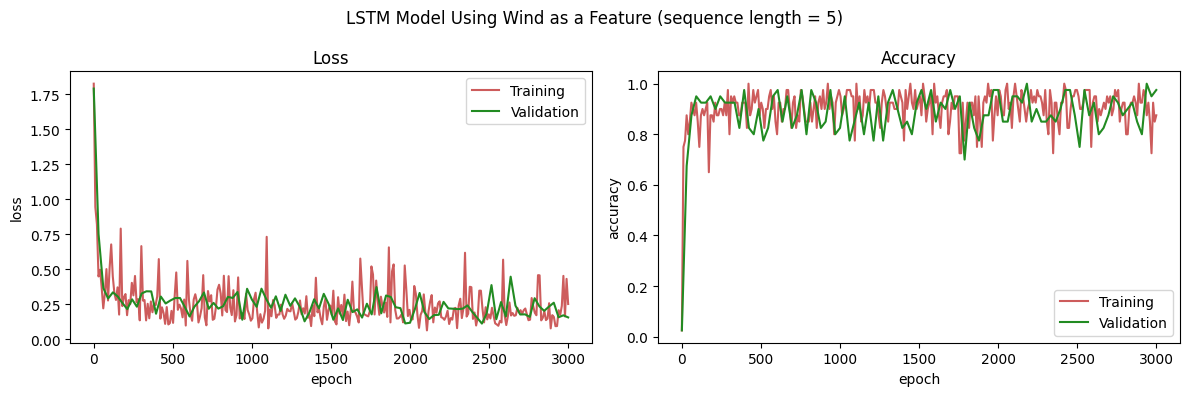

In [ ]:
n_minibatch_steps = 3000
train_log_interval = 10
val_interval = 30

# n_minibatch_steps = 10
# train_log_interval = 1
# val_interval = 1

model = lstm_model(in_size=1,out_size=6)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

train_loss, train_accuracy, val_loss, val_accuracy = train_loop(model, optimizer, train_dataloader, validate_dataloader,
                                              n_minibatch_steps, train_log_interval, val_interval)

test_loss, test_accuracy = test(model, test_dataloader)

print(f'Final train_loss: {train_loss[-1]}')
print(f'Final train_accuracy: {train_accuracy[-1]}')

print(f'Final validation_loss: {val_loss[-1]}')
print(f'Final validation_accuracy: {val_accuracy[-1]}')

print(f'Final test_loss: {test_loss}')
print(f'Final test_accuracy: {test_accuracy}')

torch.save(model.state_dict(), "lstm_model_state_dict_original.pth")

plot_outputs(train_loss, train_accuracy, val_loss, val_accuracy, [test_loss],
             [test_accuracy], train_log_interval, val_interval, 'LSTM Model Using Wind as a Feature (sequence length = 5)', False)




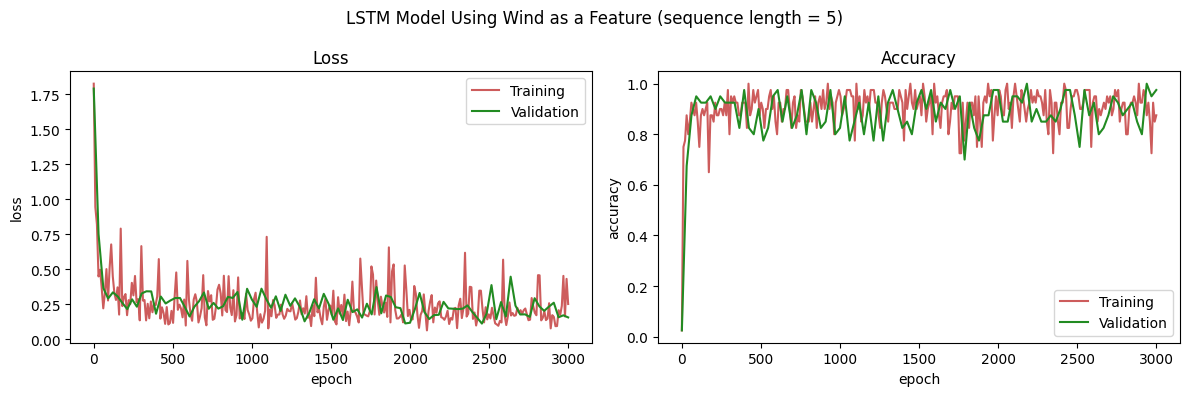

Final train_loss: 0.2507733404636383
Final train_accuracy: 0.875
Final validation_loss: 0.15493623912334442
Final validation_accuracy: 0.9749998450279236
Final test_loss: 0.07771968096494675
Final test_accuracy: 0.949999988079071


In [ ]:
plot_outputs(train_loss, train_accuracy, val_loss, val_accuracy, [test_loss],
             [test_accuracy], train_log_interval, val_interval, 'LSTM Model Using Wind as a Feature (sequence length = 5)', False)

print(f'Final train_loss: {train_loss[-1]}')
print(f'Final train_accuracy: {train_accuracy[-1]}')

print(f'Final validation_loss: {val_loss[-1]}')
print(f'Final validation_accuracy: {val_accuracy[-1]}')

print(f'Final test_loss: {test_loss}')
print(f'Final test_accuracy: {test_accuracy}')

#### Now I will take this model and fine tune it for wind as the feature

In [ ]:
class FineTunedLSTM(nn.Module):
    def __init__(self, pretrained_weights):
        super().__init__()
        # initialize pretrained model
        model = lstm_model(in_size = 1, out_size = 6)
        # replace final layer
        model.load_state_dict(pretrained_weights)
        print(model)
        # freeze all but the last layer
        for param in model.parameters():
            param.requires_grad = False
        for param in model.linear_end.parameters():
            param.requires_grad = True

        # save values
        self.net = model

    def unfreeze(self, n_layers):
        total_unfroze = 0
        for name, param in reversed(list(self.net.named_parameters())):
          if total_unfroze == n_layers:
            return
          if 'bn' in name or 'conv' in name or 'classifier' in name or 'lstm' in name or 'batchnorm' in name or 'linear' in name:
            param.requires_grad = True
            if 'weight' in name and 'fc' not in name:
              total_unfroze += 1

    def forward(self, x):
        return self.net(x)


def train_finetune(model, optimizer, n_optimization_steps, train_loader, val_loader, log_interval, val_interval, slowly_unfreeze, unfreeze_interval):
    train_loss = []
    train_accuracy = []
    val_loss = []
    val_accuracy = []
    layers_unfrozen = 1

    net = model.to(device)

    for i in tqdm(range(n_minibatch_steps)):
        x,y = next(iter(train_loader))
        x,y = x.to(device), y.to(device)

        if slowly_unfreeze == True and i % unfreeze_interval == 0:
              net.unfreeze(layers_unfrozen)
              layers_unfrozen += 1

        y_hat = net(x)
        loss = F.cross_entropy(y_hat, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if i % log_interval == 0:
          # print(y_hat)
          train_loss.append(loss.item())
          train_accuracy.append(get_accuracy(y_hat, y).item())

        if i % val_interval == 0:
          with torch.no_grad():
            l,a = validation_loop(net, val_loader)
            val_loss.append(l.item())
            val_accuracy.append(a.item())

    return train_loss, train_accuracy, val_loss, val_accuracy


lstm_model(
  (lstm): LSTM(10, 20, num_layers=5, batch_first=True)
  (lstm2): LSTM(20, 20, num_layers=5, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear_start): Linear(in_features=1, out_features=10, bias=True)
  (linear_mid): Linear(in_features=20, out_features=40, bias=True)
  (linear_end): Linear(in_features=40, out_features=6, bias=True)
  (batchnorm1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batchnorm2): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (tanh): Tanh()
  (relu): ReLU()
)


100%|██████████| 411/411 [03:48<00:00,  1.80it/s]


Final train_loss: 0.07145130634307861
Final train_accuracy: 0.9750000238418579
Final validation_loss: 0.13248807191848755
Final validation_accuracy: 0.9749998450279236
Final test_loss: 0.05843082070350647
Final test_accuracy: 1.0


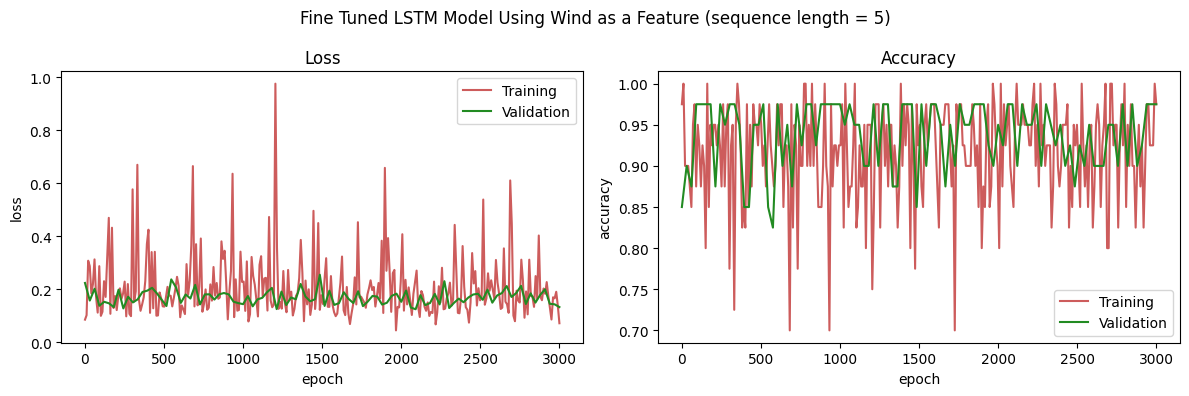

In [ ]:
n_minibatch_steps = 3000
train_log_interval = 10
val_interval = 30

# n_minibatch_steps = 10
# train_log_interval = 1
# val_interval = 1
weights = torch.load("lstm_model_state_dict_original.pth", weights_only=True, map_location=device)
model = FineTunedLSTM(weights)
model.unfreeze(2)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

train_loss, train_accuracy, val_loss, val_accuracy = train_finetune(model, optimizer, n_minibatch_steps,
                                                train_dataloader, validate_dataloader, train_log_interval, val_interval, False, 1000)

test_loss, test_accuracy = test(model, test_dataloader)

print(f'Final train_loss: {train_loss[-1]}')
print(f'Final train_accuracy: {train_accuracy[-1]}')

print(f'Final validation_loss: {val_loss[-1]}')
print(f'Final validation_accuracy: {val_accuracy[-1]}')

print(f'Final test_loss: {test_loss}')
print(f'Final test_accuracy: {test_accuracy}')

torch.save(model.state_dict(), "lstm_model_state_dict_finetuned.pth")

plot_outputs(train_loss, train_accuracy, val_loss, val_accuracy, [test_loss],
             [test_accuracy], train_log_interval, val_interval, 'Fine Tuned LSTM Model Using Wind as a Feature (sequence length = 5)', False)

lstm_model(
  (lstm): LSTM(10, 20, num_layers=5, batch_first=True)
  (lstm2): LSTM(20, 20, num_layers=5, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear_start): Linear(in_features=1, out_features=10, bias=True)
  (linear_mid): Linear(in_features=20, out_features=40, bias=True)
  (linear_end): Linear(in_features=40, out_features=6, bias=True)
  (batchnorm1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batchnorm2): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (tanh): Tanh()
  (relu): ReLU()
)


100%|██████████| 411/411 [01:26<00:00,  4.76it/s]


Final train_loss: 0.15362130105495453
Final train_accuracy: 0.925000011920929
Final validation_loss: 0.1672162562608719
Final validation_accuracy: 0.9000001549720764
Final test_loss: 0.06198326498270035
Final test_accuracy: 1.0


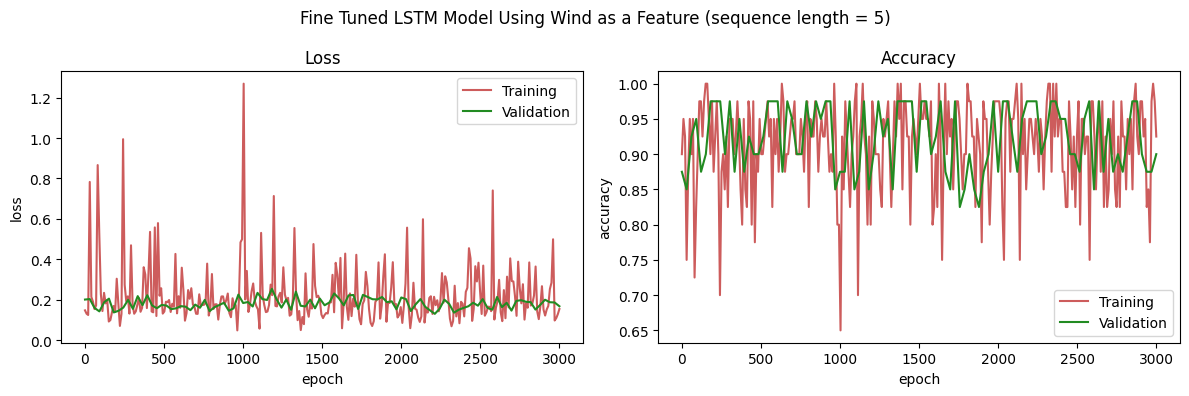

In [ ]:
n_minibatch_steps = 3000
train_log_interval = 10
val_interval = 30

# n_minibatch_steps = 10
# train_log_interval = 1
# val_interval = 1
weights = torch.load("lstm_model_state_dict_original.pth", weights_only=True, map_location=device)
model = FineTunedLSTM(weights)
model.unfreeze(2)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

train_loss, train_accuracy, val_loss, val_accuracy = train_finetune(model, optimizer, n_minibatch_steps,
                                                train_dataloader, validate_dataloader, train_log_interval, val_interval, True, 1500)

test_loss, test_accuracy = test(model, test_dataloader)

print(f'Final train_loss: {train_loss[-1]}')
print(f'Final train_accuracy: {train_accuracy[-1]}')

print(f'Final validation_loss: {val_loss[-1]}')
print(f'Final validation_accuracy: {val_accuracy[-1]}')

print(f'Final test_loss: {test_loss}')
print(f'Final test_accuracy: {test_accuracy}')

torch.save(model.state_dict(), "lstm_model_state_dict_finetuned_freeze.pth")

plot_outputs(train_loss, train_accuracy, val_loss, val_accuracy, [test_loss],
             [test_accuracy], train_log_interval, val_interval, 'Fine Tuned LSTM Model Using Wind as a Feature (sequence length = 5)', False)

#### Compare results with a simple convolution model

In [ ]:
class ConvModel(nn.Module):
    def __init__(self, in_size, out_size, sequence_length):
        super().__init__()
        self.in_size = in_size
        self.out_size = out_size
        self.sequence_length = sequence_length

        self.conv1 = nn.Conv1d(in_channels = in_size, out_channels = 20, kernel_size = 1)
        self.conv2 = nn.Conv1d(in_channels = 20, out_channels = 60, kernel_size = 1)
        self.conv3 = nn.Conv1d(in_channels = 60, out_channels = 20, kernel_size = 1)
        self.linear_end = nn.Conv1d(in_channels = 20, out_channels = out_size, kernel_size = 1)

        self.dropout = nn.Dropout(p = 0.4)
        self.relu = nn.ReLU()

        self.batchnorm1 = torch.nn.BatchNorm1d(20)
        self.batchnorm2 = torch.nn.BatchNorm1d(60)
        self.batchnorm3 = torch.nn.BatchNorm1d(6)

    def forward(self,x):
        if len(x.shape) != 3:
          x = x.unsqueeze(dim = 2)
        b,s,l = x.shape
        layer1 = self.dropout(self.relu(self.batchnorm1(self.conv1(x.view(b,l,s)))))
        layer2 = self.dropout(self.relu(self.batchnorm2(self.conv2(layer1))))
        layer3 = self.dropout(self.relu(self.batchnorm1(self.conv3(layer2))))
        layer4 = self.relu(self.batchnorm3(self.linear_end(layer3)))
        return layer4[:,:,-1]

100%|██████████| 124/124 [00:17<00:00,  6.94it/s]


Final train_loss: 0.4458155035972595
Final train_accuracy: 0.875
Final validation_loss: 0.3899197280406952
Final validation_accuracy: 0.7250000238418579
Final test_loss: 0.39752477407455444
Final test_accuracy: 0.875


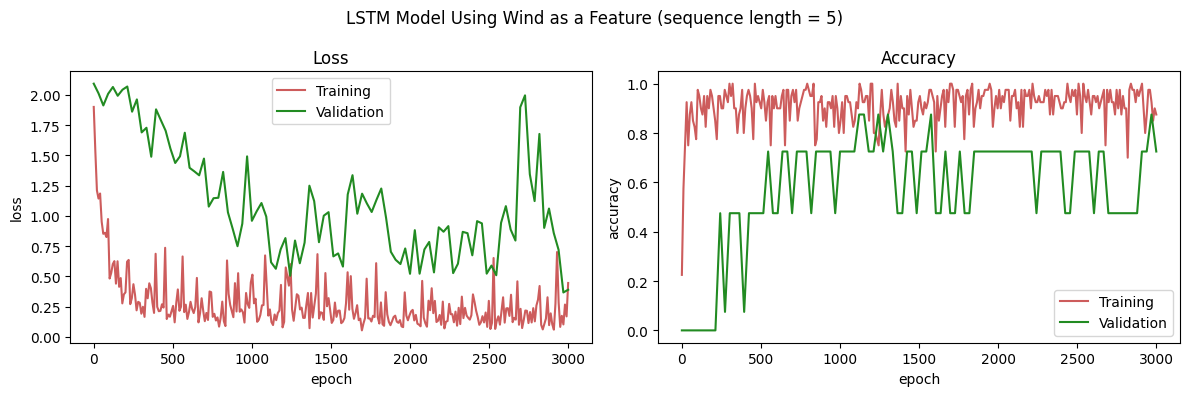

In [ ]:
# try first with same sequential

n_minibatch_steps = 3000
train_log_interval = 10
val_interval = 30

# n_minibatch_steps = 10
# train_log_interval = 1
# val_interval = 1

model = ConvModel(in_size=1,out_size=6, sequence_length = 5)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

train_loss, train_accuracy, val_loss, val_accuracy = train_loop(model, optimizer, train_dataloader, validate_dataloader,
                                              n_minibatch_steps, train_log_interval, val_interval)

test_loss, test_accuracy = test(model, test_dataloader)

print(f'Final train_loss: {train_loss[-1]}')
print(f'Final train_accuracy: {train_accuracy[-1]}')

print(f'Final validation_loss: {val_loss[-1]}')
print(f'Final validation_accuracy: {val_accuracy[-1]}')

print(f'Final test_loss: {test_loss}')
print(f'Final test_accuracy: {test_accuracy}')

torch.save(model.state_dict(), "lstm_model_state_dict_conv.pth")

plot_outputs(train_loss, train_accuracy, val_loss, val_accuracy, [test_loss],
             [test_accuracy], train_log_interval, val_interval, 'LSTM Model Using Wind as a Feature (sequence length = 5)', False)




100%|██████████| 249/249 [03:38<00:00,  1.14it/s]


Final train_loss: 0.17150235176086426
Final train_accuracy: 0.949999988079071
Final validation_loss: 2.9438586235046387
Final validation_accuracy: 0.12439758330583572
Final test_loss: 4.013855934143066
Final test_accuracy: 0.0


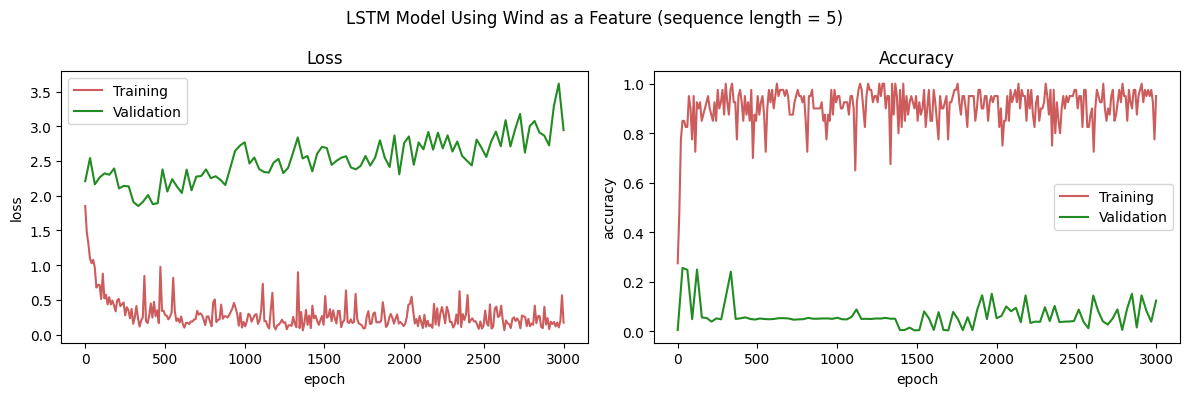

In [ ]:
# Then try with just the wind score
train_dataloader = DataLoader(DataSet_model1(train['max_wind'].values, train['category'].values), batch_size = 40, shuffle = True, num_workers = 2)
validate_dataloader = DataLoader(DataSet_model1(train['max_wind'].values, train['category'].values), batch_size = 40, shuffle = True, num_workers = 2)
test_dataloader = DataLoader(DataSet_model1(train['max_wind'].values, train['category'].values), batch_size = 40, shuffle = False, num_workers = 2)

n_minibatch_steps = 3000
train_log_interval = 10
val_interval = 30

# n_minibatch_steps = 10
# train_log_interval = 1
# val_interval = 1

model = ConvModel(in_size=1,out_size=6, sequence_length = 1)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

train_loss, train_accuracy, val_loss, val_accuracy = train_loop(model, optimizer, train_dataloader, validate_dataloader,
                                              n_minibatch_steps, train_log_interval, val_interval, dim = 1)

test_loss, test_accuracy = test(model, test_dataloader, dim = 1)

print(f'Final train_loss: {train_loss[-1]}')
print(f'Final train_accuracy: {train_accuracy[-1]}')

print(f'Final validation_loss: {val_loss[-1]}')
print(f'Final validation_accuracy: {val_accuracy[-1]}')

print(f'Final test_loss: {test_loss}')
print(f'Final test_accuracy: {test_accuracy}')

torch.save(model.state_dict(), "lstm_model_state_dict_conv_1d.pth")

plot_outputs(train_loss, train_accuracy, val_loss, val_accuracy, [test_loss],
             [test_accuracy], train_log_interval, val_interval, 'LSTM Model Using Wind as a Feature (sequence length = 5)', False)

### Try adding Pacific and Atlantic data together to see if this will make it better

In [10]:
atlantic_hur_dat = pd.read_csv('Processed_hurricane_florida_data.csv', index_col = 'date')
pacific_hur_dat = pd.read_csv('Processed_hurricane_hawaii_data.csv', index_col = 'date')

atlantic_hur_dat.drop(atlantic_hur_dat.columns[0], axis = 1, inplace = True)
atlantic_hur_dat.loc[atlantic_hur_dat['min_pressure'] == -999, 'min_pressure'] = np.nan
atlantic_hur_dat.loc[atlantic_hur_dat['max_wind'] == -999, 'max_wind'] = np.nan
print(len(atlantic_hur_dat))
print(atlantic_hur_dat.columns)

pacific_hur_dat.drop(pacific_hur_dat.columns[0], axis = 1, inplace = True)
pacific_hur_dat.loc[pacific_hur_dat['min_pressure'] == -999, 'min_pressure'] = np.nan
pacific_hur_dat.loc[pacific_hur_dat['max_wind'] == -999, 'max_wind'] = np.nan
print(len(pacific_hur_dat))
print(pacific_hur_dat.columns)

54749
Index(['storm_id', 'storm_name', 'time', 'status', 'latitude', 'longitude',
       'max_wind', 'min_pressure', 'category'],
      dtype='object')
23354
Index(['storm_id', 'storm_name', 'time', 'status', 'latitude', 'longitude',
       'max_wind', 'min_pressure', 'category'],
      dtype='object')


In [11]:
# atlantic_hur_dat = atlantic_hur_dat.dropna(subset=['max_wind', 'category'])

train_atlantic = atlantic_hur_dat[:int(len(atlantic_hur_dat)*.65)]
validate_atlantic = atlantic_hur_dat[int(len(atlantic_hur_dat)*.65): int(len(atlantic_hur_dat)*.7)]
test_atlantic = atlantic_hur_dat[int(len(atlantic_hur_dat)*.7):]

train_pacific = pacific_hur_dat[:int(len(pacific_hur_dat)*.65)]
validate_pacific = pacific_hur_dat[int(len(pacific_hur_dat)*.65): int(len(atlantic_hur_dat)*.7)]
test_pacific = pacific_hur_dat[int(len(pacific_hur_dat)*.7):]

sequence_length = 15
train_sequences_a, train_labels_a = create_sequences(train_atlantic[['max_wind', 'min_pressure']].values, train_atlantic['category'].values, sequence_length)
validate_sequences_a, validate_labels_a = create_sequences(validate_atlantic[['max_wind', 'min_pressure']].values, validate_atlantic['category'].values, sequence_length)
test_sequences_a, test_labels_a = create_sequences(test_atlantic[['max_wind', 'min_pressure']].values, test_atlantic['category'].values, sequence_length)

train_sequences_p, train_labels_p = create_sequences(train_pacific[['max_wind', 'min_pressure']].values, train_pacific['category'].values, sequence_length)
validate_sequences_p, validate_labels_p = create_sequences(validate_pacific[['max_wind', 'min_pressure']].values, validate_pacific['category'].values, sequence_length)
test_sequences_p, test_labels_p = create_sequences(test_pacific[['max_wind', 'min_pressure']].values, test_pacific['category'].values, sequence_length)

# print(train_sequences_a.shape, train_sequences_p.shape)
train_sequences = torch.cat([train_sequences_a, train_sequences_p], dim = 0)
validate_sequences = torch.cat([validate_sequences_a, validate_sequences_p], dim = 0)
test_sequences = torch.cat([test_sequences_a, test_sequences_p], dim = 0)

train_labels = torch.cat([train_labels_a, train_labels_p], axis = 0)
validate_labels = torch.cat([validate_labels_a, validate_labels_p], axis = 0)
test_labels = torch.cat([test_labels_a, test_labels_p], axis = 0)


train_dataloader = DataLoader(DataSet_model1(train_sequences, train_labels), batch_size=40, shuffle=True, num_workers=2)
validate_dataloader = DataLoader(DataSet_model1(validate_sequences, validate_labels), batch_size=40, shuffle=False, num_workers=2)
test_dataloader = DataLoader(DataSet_model1(test_sequences, test_labels), batch_size=40, shuffle=False, num_workers=2)


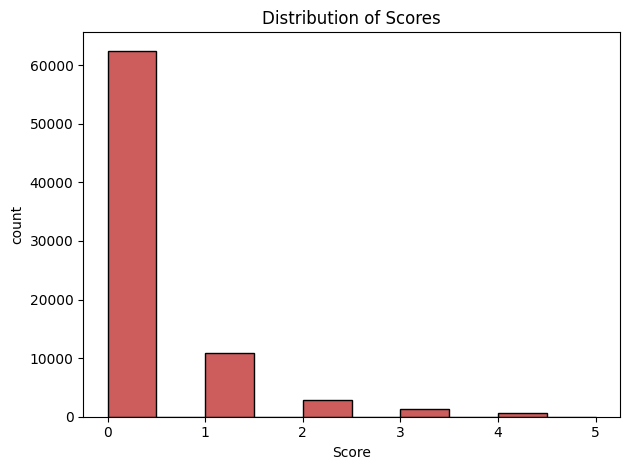

In [ ]:
plt.hist(list(atlantic_hur_dat['category']) + list(pacific_hur_dat['category']), color = 'indianred', edgecolor = 'k')
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('count')
plt.tight_layout()
plt.show()

In [12]:
def validation_loop(net, validate_dataloader):
    net.eval()
    loss = []
    accuracy = []
    for i in range(len(validate_dataloader)):
      x,y = next(iter(validate_dataloader))
      x,y = x.to(device), y.to(device)
      y_hat = net(x)
      loss.append(F.cross_entropy(y_hat, y).item())
      accuracy.append(get_accuracy(y_hat, y).item())
    net.train()
    return torch.sum(torch.tensor(loss))/len(loss), torch.sum(torch.tensor(accuracy))/len(loss)

def train_loop(net, optimizer, train_dataloader, val_dataloader, n_minibatch_steps, log_interval, val_interval):
    train_loss = []
    train_accuracy = []
    val_loss = []
    val_accuracy = []

    network = net.to(device)

    for i in tqdm(range(n_minibatch_steps)):
        x,y = next(iter(train_dataloader))
        x,y = x.to(device), y.to(device)
        y_hat = network(x)
        loss = F.cross_entropy(y_hat, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if i % log_interval == 0:
          # print(y_hat)
          train_loss.append(loss.item())
          train_accuracy.append(get_accuracy(y_hat, y).item())
        if i % val_interval == 0:
          with torch.no_grad():
            l,a = validation_loop(net, val_dataloader)
            val_loss.append(l.item())
            val_accuracy.append(a.item())

    return train_loss, train_accuracy, val_loss, val_accuracy

@torch.no_grad()
def test(net, test_dataloader):
    net.eval()
    loss = []
    accuracy = []
    for i in tqdm(range(len(test_dataloader))):
      x,y = next(iter(test_dataloader))
      x,y = x.to(device), y.to(device)
      y_hat = net(x)
      loss.append(F.cross_entropy(y_hat, y).item())
      accuracy.append(get_accuracy(y_hat, y).item())
    net.train()
    return np.mean(loss), np.mean(accuracy)

In [13]:
class lstm_model(nn.Module):
  def __init__(self, in_size, out_size, num_layers = 5):
    super().__init__()
    self.in_size = in_size
    self.out_size = out_size
    self.num_layers = num_layers
    self.lstm = nn.LSTM(input_size=10, hidden_size=20, num_layers=num_layers, batch_first=True)
    self.lstm2 = nn.LSTM(input_size=20, hidden_size=20, num_layers=num_layers, batch_first=True)
    self.dropout = nn.Dropout(p = .2)
    self.linear_start = nn.Linear(in_features = in_size, out_features = 10)
    self.linear_mid = nn.Linear(in_features = 20, out_features = 40)
    self.linear_end = nn.Linear(in_features = 40, out_features = out_size)
    self.batchnorm1 = nn.BatchNorm1d(10)
    self.batchnorm2 = nn.BatchNorm1d(20)
    self.tanh = nn.Tanh()
    self.relu = nn.ReLU()

  def forward(self, x):
    h_0 = torch.zeros(self.num_layers, x.size(0), 20).to(device)
    c_0 = torch.zeros(self.num_layers, x.size(0), 20).to(device)

    layer1 = self.tanh(self.dropout(self.batchnorm1(self.linear_start(x.view(-1, self.in_size)))))
    layer2, memory = self.lstm(layer1.view(x.size(0), x.size(1), -1), (h_0, c_0))
    layer3 = self.tanh(self.batchnorm2(self.dropout(layer2.reshape(-1, 20))))
    layer4, _ = self.lstm2(layer3.reshape(x.size(0), x.size(1), -1), memory)
    layer5 = self.relu(self.linear_mid(layer4[:,-1,:]))
    return self.relu(self.linear_end(layer5))



100%|██████████| 586/586 [07:42<00:00,  1.27it/s]


Final train_loss: nan
Final train_accuracy: 0.824999988079071
Final validation_loss: nan
Final validation_accuracy: 0.8249998092651367
Final test_loss: nan
Final test_accuracy: 1.0


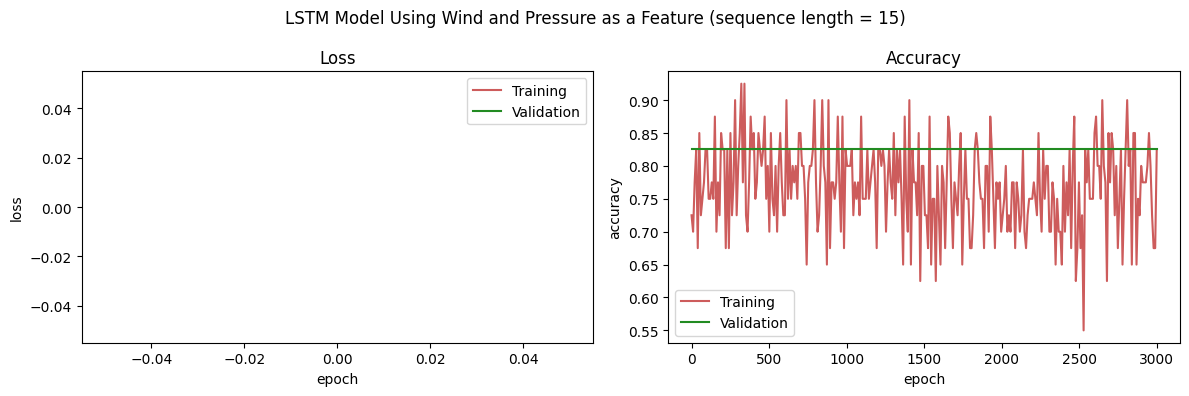

In [ ]:
n_minibatch_steps = 3000
train_log_interval = 10
val_interval = 30

# n_minibatch_steps = 10
# train_log_interval = 1
# val_interval = 1

model = lstm_model(in_size=2,out_size=6, num_layers = 15)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

train_loss, train_accuracy, val_loss, val_accuracy = train_loop(model, optimizer, train_dataloader, validate_dataloader,
                                              n_minibatch_steps, train_log_interval, val_interval)

test_loss, test_accuracy = test(model, test_dataloader)

print(f'Final train_loss: {train_loss[-1]}')
print(f'Final train_accuracy: {train_accuracy[-1]}')

print(f'Final validation_loss: {val_loss[-1]}')
print(f'Final validation_accuracy: {val_accuracy[-1]}')

print(f'Final test_loss: {test_loss}')
print(f'Final test_accuracy: {test_accuracy}')

torch.save(model.state_dict(), "lstm_model_state_dict_full.pth")

plot_outputs(train_loss, train_accuracy, val_loss, val_accuracy, [test_loss],
             [test_accuracy], train_log_interval, val_interval, 'LSTM Model Using Wind and Pressure as a Feature (sequence length = 15)', False)

## Attempt to classify the peak storm classification

In [14]:
class DataSet_PeakClassification(Dataset):
    def __init__(self, dataframe, features):
        self.dataframe = dataframe
        self.features = features

        self.unique_storm_ids = self.dataframe['storm_id'].unique()

    def __len__(self):
        return len(self.unique_storm_ids)

    def __getitem__(self, index):
        storm_id = self.unique_storm_ids[index]

        storm_data = self.dataframe[self.dataframe['storm_id'] == storm_id]

        features_tensor = torch.tensor(storm_data[self.features].values, dtype=torch.float32)
        max_category = torch.tensor(storm_data['category'].max(), dtype=torch.long)

        return features_tensor, max_category


In [17]:
hurdat = pd.read_csv('Processed_hurricane_florida_data.csv', index_col = 'date')
hurdat.drop(hurdat.columns[0], axis = 1, inplace = True)
hurdat.loc[hurdat['min_pressure'] == -999, 'min_pressure'] = np.nan
hurdat.loc[hurdat['max_wind'] == -999, 'max_wind'] = np.nan
hurdat.index = pd.to_datetime(hurdat.index)
hurdat['year'] = hurdat.index.year
hurdat['month'] = hurdat.index.year

temp = pd.read_csv('Processed_florida_temp_data.csv', index_col = 'Date')
temp.index = pd.to_datetime(temp.index)
temp['year'] = temp.index.year
temp['Temperature'] = pd.to_numeric(temp['Temperature'], errors='coerce')
temp.loc[temp['Temperature'] == -9999] = np.nan
temp.dropna(subset=['Temperature'], inplace=True)

prcp = pd.read_csv('Processed_florida_prcp_data.csv', index_col = 'Date')
prcp['Precipitation (mm)'] = pd.to_numeric(prcp['Precipitation (mm)'], errors='coerce')
prcp.index = pd.DatetimeIndex(prcp.index)
prcp['year'] = prcp.index.year
prcp['month'] = prcp.index.month

merged_data = pd.merge(hurdat, prcp[['Precipitation (mm)', 'year', 'month']],
                       on=['year', 'month'], how='left')

FLORIDA = pd.merge(merged_data, temp[['Temperature', 'year']], on = ['year'], how = 'left')



In [15]:
hurdat = pd.read_csv('Processed_hurricane_hawaii_data.csv', index_col = 'date')
hurdat.drop(hurdat.columns[0], axis = 1, inplace = True)
hurdat.loc[hurdat['min_pressure'] == -999, 'min_pressure'] = np.nan
hurdat.loc[hurdat['max_wind'] == -999, 'max_wind'] = np.nan
hurdat.index = pd.to_datetime(hurdat.index)
hurdat['year'] = hurdat.index.year
hurdat['month'] = hurdat.index.year

temp = pd.read_csv('Processed_hawaii_temp_data.csv', index_col = 'Date')
temp.index = pd.to_datetime(temp.index)
temp['year'] = temp.index.year
temp['Temperature'] = pd.to_numeric(temp['Temperature'], errors='coerce')
temp.loc[temp['Temperature'] == -9999] = np.nan
temp.dropna(subset=['Temperature'], inplace=True)

prcp = pd.read_csv('Processed_hawaii_prcp_data.csv', index_col = 'Date')
prcp['Precipitation (mm)'] = pd.to_numeric(prcp['Precipitation (mm)'], errors='coerce')
prcp.index = pd.DatetimeIndex(prcp.index)
prcp['year'] = prcp.index.year
prcp['month'] = prcp.index.month

merged_data = pd.merge(hurdat, prcp[['Precipitation (mm)', 'year', 'month']],
                       on=['year', 'month'], how='left')

HAWAII = pd.merge(merged_data, temp[['Temperature', 'year']], on = ['year'], how = 'left')

In [18]:
FLORIDA = FLORIDA.dropna(subset=['max_wind', 'min_pressure'])
HAWAII = HAWAII.dropna(subset=['max_wind', 'min_pressure'])

In [ ]:
HAWAII

,storm_id,storm_name,time,status,latitude,longitude,max_wind,min_pressure,category,year,month,Precipitation (mm),Temperature
0,EP011949,UNNAMED,0,TS,20.2N,106.3W,45.0,NaN,0,1949,1949,NaN,NaN
1,EP011949,UNNAMED,600,TS,20.2N,106.4W,45.0,NaN,0,1949,1949,NaN,NaN
2,EP011949,UNNAMED,1200,TS,20.2N,106.7W,45.0,NaN,0,1949,1949,NaN,NaN
3,EP011949,UNNAMED,1800,TS,20.3N,107.7W,45.0,NaN,0,1949,1949,NaN,NaN
4,EP011949,UNNAMED,0,TS,20.4N,108.6W,45.0,NaN,0,1949,1949,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23349,EP092011,HILARY,0,LO,23.8N,122.4W,30.0,1007.0,0,2011,2011,NaN,NaN
23350,EP092011,HILARY,600,LO,23.8N,122.7W,25.0,1008.0,0,2011,2011,NaN,NaN
23351,EP092011,HILARY,1200,LO,23.7N,123.0W,25.0,1008.0,0,2011,2011,NaN,NaN
23352,EP092011,HILARY,1800,LO,23.5N,123.3W,25.0,1009.0,0,2011,2011,NaN,NaN


In [19]:
# atlantic_hur_dat = atlantic_hur_dat.dropna(subset=['max_wind', 'category'])

train_atlantic = FLORIDA[:int(len(FLORIDA)*.65)]
validate_atlantic = FLORIDA[int(len(FLORIDA)*.65): int(len(FLORIDA)*.7)]
test_atlantic = FLORIDA[int(len(FLORIDA)*.7):]

train_pacific = HAWAII[:int(len(HAWAII)*.65)]
validate_pacific = HAWAII[int(len(HAWAII)*.65): int(len(HAWAII)*.7)]
test_pacific = HAWAII[int(len(HAWAII)*.7):]

# print(train_sequences_a.shape, train_sequences_p.shape)
train_sequences = pd.concat([train_atlantic, train_pacific], axis = 0)
validate_sequences = pd.concat([validate_atlantic, validate_pacific], axis = 0)
test_sequences = pd.concat([test_atlantic, test_pacific], axis = 0)


train_dataloader = DataLoader(DataSet_PeakClassification(train_sequences, ['max_wind', 'min_pressure']), batch_size=40, shuffle=True, num_workers=2)
validate_dataloader = DataLoader(DataSet_PeakClassification(validate_sequences, ['max_wind', 'min_pressure']), batch_size=40, shuffle=False, num_workers=2)
test_dataloader = DataLoader(DataSet_PeakClassification(test_sequences, ['max_wind', 'min_pressure']), batch_size=40, shuffle=False, num_workers=2)


In [ ]:
td = DataSet_PeakClassification(train_sequences, ['max_wind', 'min_pressure'])
print(f"Dataset length: {len(td)}")
# print(f"Unique storm IDs: {td.unique_storm_ids}")
print(td[0])
print(td[1])



Dataset length: 932
0
(tensor([[100., 961.]]), tensor(2))
1
(tensor([[130., 924.]]), tensor(4))


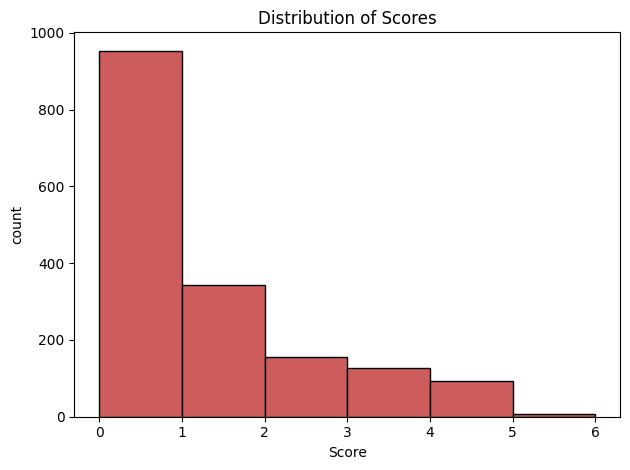

In [ ]:
# plt.hist(list(FLORIDA['category']) + list(HAWAII['category']), color = 'indianred', edgecolor = 'k')
# plt.title('Distribution of Scores')
# plt.xlabel('Score')
# plt.ylabel('count')
# plt.tight_layout()
# plt.show()


# Extract the maximum category for each storm in FLORIDA
florida_max_category = FLORIDA.groupby('storm_id')['category'].max()

# Extract the maximum category for each storm in HAWAII
hawaii_max_category = HAWAII.groupby('storm_id')['category'].max()

# Combine the results into a single list
all_max_categories = list(florida_max_category) + list(hawaii_max_category)

# Plot the histogram
plt.hist(all_max_categories, color='indianred', edgecolor='k', bins=range(int(max(all_max_categories)) + 2))
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('count')
plt.tight_layout()
plt.show()


In [ ]:
class DataSet_PeakClassification(Dataset):
    def __init__(self, dataframe, features):
        self.dataframe = dataframe.reset_index(drop=True)  # Reset index to ensure proper alignment
        self.features = features
        self.unique_storm_ids = self.dataframe['storm_id'].unique()

    def __len__(self):
        return len(self.unique_storm_ids)

    def __getitem__(self, index):
        # Map positional index to storm ID
        storm_id = self.unique_storm_ids[index]

        # Filter data for the current storm ID
        storm_data = self.dataframe[self.dataframe['storm_id'] == storm_id]

        # Extract features and max category
        features_tensor = torch.tensor(storm_data[self.features].values, dtype=torch.float32)
        max_category = torch.tensor(storm_data['category'].max(), dtype=torch.long)

        return features_tensor, max_category


In [ ]:
n_minibatch_steps = 3000
train_log_interval = 10
val_interval = 30

# n_minibatch_steps = 10
# train_log_interval = 1
# val_interval = 1

model = lstm_model(in_size=2,out_size=6, num_layers = 15)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

train_loss, train_accuracy, val_loss, val_accuracy = train_loop(model, optimizer, train_dataloader, validate_dataloader,
                                              n_minibatch_steps, train_log_interval, val_interval)

test_loss, test_accuracy = test(model, test_dataloader)

print(f'Final train_loss: {train_loss[-1]}')
print(f'Final train_accuracy: {train_accuracy[-1]}')

print(f'Final validation_loss: {val_loss[-1]}')
print(f'Final validation_accuracy: {val_accuracy[-1]}')

print(f'Final test_loss: {test_loss}')
print(f'Final test_accuracy: {test_accuracy}')

torch.save(model.state_dict(), "lstm_model_state_dict_full.pth")

plot_outputs(train_loss, train_accuracy, val_loss, val_accuracy, [test_loss],
             [test_accuracy], train_log_interval, val_interval, 'LSTM Model Using Wind and Pressure as a Feature (sequence length = 15)', False)

  0%|          | 0/3000 [00:01<?, ?it/s]


RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/worker.py", line 351, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/fetch.py", line 55, in fetch
    return self.collate_fn(data)
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/collate.py", line 398, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/collate.py", line 211, in collate
    return [
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/collate.py", line 212, in <listcomp>
    collate(samples, collate_fn_map=collate_fn_map)
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/collate.py", line 155, in collate
    return co